# Week 3 Lecture: Linear Regression for Prediction

This week we are going to use the movie dataset to try to answer this question: 
        
- **Can we predict the revenue of a movie based on its characteristics?**

For prediction we will use a **linear regression model**.

## What is Linear Regression?

Linear regression is a statistical method for modeling the relationship between:
- A **response variable** (or dependent variable, outcome) - what we want to predict

- One or more **predictor variables** (or independent variables, features) - information we use to make predictions

- The main idea is: if we have past movies where we know both the characteristics and the revenue, we can **learn** a rule that uses the characteristics to predict revenue for new movies.

## The Linear Regression Model (Conceptually)

In the simplest case, we use one piece of information to predict the outcome (for example, budget to predict revenue).

Linear regression assumes the relationship is roughly straight-line shaped, meaning as the predictor increases, the outcome tends to increase (or decrease) in a fairly steady way.

The model has three main parts:

- A baseline starting point:
This is the model’s “default” prediction when the predictor is at its lowest/reference point.

- An adjustment rule:
This describes how the prediction changes when the predictor increases.
For example: “For each extra unit of budget, the predicted revenue goes up by about this much.”
- Unexplained variation (noise):

NB: Even with a good rule, movies don’t all behave the same way.
Two movies with the same budget can make very different revenue due to factors we didn’t include (marketing, competition, reviews, timing, luck, etc.). Linear regression acknowledges that there will always be some randomness and missing factors.

## The Linear Regression Model (Mathematically)

The simplest form is **simple linear regression** with one predictor:

$$y = \beta_0 + \beta_1 x + \epsilon$$

Where:
- $y$ is the response variable (e.g., movie revenue)
- $x$ is the predictor variable (e.g., movie budget)
- $\beta_0$ is the intercept (baseline value when $x = 0$)
- $\beta_1$ is the slope (how much $y$ changes when $x$ increases by 1)
- $\epsilon$ is the error term (unexplained variation)

**Predictions** from this model are new values of $y$ called $\hat y$ that we make from the fitted regression line. So, $\hat y = \hat \beta_0 + \hat \beta_1 x_1$ for a simple two-variable regression.

![Regression Visualization](images/regression-visual.png)
Figure 1. Regression line showing the errors (vertical distances from the data point to line) of the fitted line and $\hat y = \hat \beta_0 +\hat\beta_1 x$

## What the Scatterplot is Showing

- Dots = real movies in the dataset

- A line = the model’s best overall trend for predicting revenue from the predictor

- Vertical gaps from dots to the line = the model’s “misses” (prediction errors)

A good model has dots that tend to cluster closer to the line (smaller errors), though there will almost always be some spread.

## What “Prediction” Means Here

Once we learn the best straight-line rule from the data, we can use it to:

- plug in a movie’s characteristics (like budget) into the regression equation and get a predicted revenue.

That predicted value is basically:

**“What the line says revenue should be for a movie like this.”**

## Multiple Linear Regression (Conceptually)

- Multiple linear regression is a way to predict one outcome using several pieces of information at once (e.g., predict movie revenue using budget, genre, runtime, star power, and release month).

- It learns a baseline prediction, then makes separate adjustments for each feature, combining them into one final estimate.

- Each feature’s adjustment answers: “How does the prediction change when this one feature increases, assuming the others stay the same?”

- The model picks the “best” set of adjustments by finding the combination that, overall, produces predictions that are closest to the real outcomes across the dataset.

- There will still be unexplained variation because movies are affected by factors not in the model (marketing, competition, reviews, randomness), so predictions won’t be perfect even with many features.

- Adding more features can improve predictions, but it can also overfit (memorize noise), so we usually check performance on new data, not just the training data.

## Multiple Linear Regression (Mathematically)

With multiple predictors, we extend to:

$$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_p x_p + \epsilon$$

For example, predicting movie revenue using budget, runtime, and popularity:

$$\text{revenue} = \beta_0 + \beta_1 \times \text{budget} + \beta_2 \times \text{runtime} + \beta_3 \times \text{popularity} + \epsilon$$

## How Do We Find the Best Line?

Linear regression models are fit using a method called **least squares**. This method finds the values of $\beta_0$, $\beta_1$, $\beta_2$, etc. that minimize the sum of squared errors. The values are $\hat \beta_0$, $\hat \beta_1$, $\hat \beta_2$

- An **error** (or residual) is the difference between the actual value and the predicted value: $e_i = y_i - \hat{y}_i$

- We want to make these errors as small as possible overall

- The least squares method finds the coefficients that minimize: 

$$\sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

In other words, we find the line that gets as close as possible to all the data points, where "close" is measured by squared vertical distances.

## Why Use Linear Regression for Prediction?

- **Interpretable**: The $\hat \beta$ coefficients tell us how each predictor variable affects the outcome

- **Easy model evaluation**: There are easy ways to assess model fit (e.g., coefficient of determination $R^2$, root mean squared error RMSE, mean absolute error MAE)

- **Fast**: Quick to fit and make predictions

- **Baseline**: Good starting point before trying complex models

- **Works well**: Often performs surprisingly well despite simplicity

## Python for Linear Regression

- We will use Python's `statsmodels` to fit linear regression models that explore the relationships between movie features and revenue. This library allows us to fit the models, explore the estimated $\hat \beta$ coefficients, evaluate the model with built-in diagnostics, and evaluate prediction accuracy.

## Loading in the Data
- We will load the data with `pandas`

- **Data Source**: [The Movie Database (TMDB) API](https://www.themoviedb.org/)  

- **Code to call the API**: The code used to pull these data from the API are available [in this file](./movieDB.py)

- **Date Range**: Movies released between 2015-01-01 and 2025-12-31

- The dataset contains information about 5,000 movies, but let's load it and check

In [201]:
import pandas as pd
pd.set_option("display.float_format", "{:.2f}".format) 

movies = pd.read_csv("movies.csv")   
print(movies.shape)
print(movies.head(3).to_string(index=False))

(5000, 17)
 movie_id                    title    revenue  popularity    budget release_date  runtime                                   genres  vote_average                                                                 production_companies production_countries                                                                                                      actors                                                                                                        crews  actor_avg_pop  crew_avg_pop  cast_count  crew_count
    19995                   Avatar 2923706026       54.76 237000000   2009-12-16      162 Action,Adventure,Fantasy,Science Fiction          7.60 Dune Entertainment,Lightstorm Entertainment,20th Century Fox,Ingenious Film Partners                US,GB   Sam Worthington(6.2), Zoe Saldaña(9.9), Sigourney Weaver(5.3), Stephen Lang(4.1), Michelle Rodriguez(4.1)            John Refoua(0.2), Stephen E. Rivkin(0.2), Terry Notary(0.4), James Cameron(4.1), Mauro Fiore(0.4) 

### Data Dictionary

The movie dataset contains the following variables:

| Variable | Type | Description |
|----------|------|-------------|
| `movie_id` | int | Unique identifier from TMDB (The Movie Database) |
| `title` | string | Movie title |
| `revenue` | int | Worldwide box office revenue in USD |
| `popularity` | float | TMDB popularity score (higher = more popular) |
| `budget` | int | Production budget in USD |
| `release_date` | string | Release date (YYYY-MM-DD format) |
| `runtime` | int | Movie duration in minutes |
| `genres` | string | Comma-separated list of genres (e.g., "Action,Adventure") |
| `vote_average` | float | Average user rating (0-10 scale) |
| `production_companies` | string | Comma-separated list of production companies |
| `production_countries` | string | Comma-separated country codes (e.g., "US,GB") |
| `actors` | string | Top 5 actors with their popularity scores |
| `crews` | string | Top 5 crew members with their popularity scores |
| `actor_avg_pop` | float | Average popularity of top 5 actors |
| `crew_avg_pop` | float | Average popularity of top 5 crew members |
| `cast_count` | int | Total number of cast members |
| `crew_count` | int | Total number of crew members |

## Simple Linear Regression: can we predict movie revenue from its budget?

- Let's take a look at these variables in our dataset

In [202]:
# Check for missing values
movies[['revenue', 'budget']].isna().sum()

revenue    0
budget     0
dtype: int64

In [203]:
# Summary statistics for revenue
movies['revenue'].describe()

count         5000.00
mean     124749041.81
std      211172120.67
min        8826094.00
25%       20000000.00
50%       48152392.50
75%      133435207.75
max     2923706026.00
Name: revenue, dtype: float64

In [204]:
# Summary statistics for budget
movies['budget'].describe()

count        5000.00
mean     35021982.87
std      49405542.78
min             0.00
25%       4000000.00
50%      17500000.00
75%      42054821.25
max     583900000.00
Name: budget, dtype: float64

- Now let's make some basic exploratory plots using `matplotlib`. Histograms are most appropriate for continuous numeric data to see the distributions of the two variables of interest

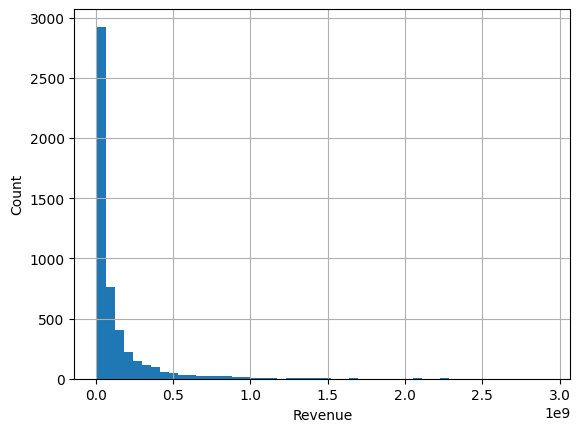

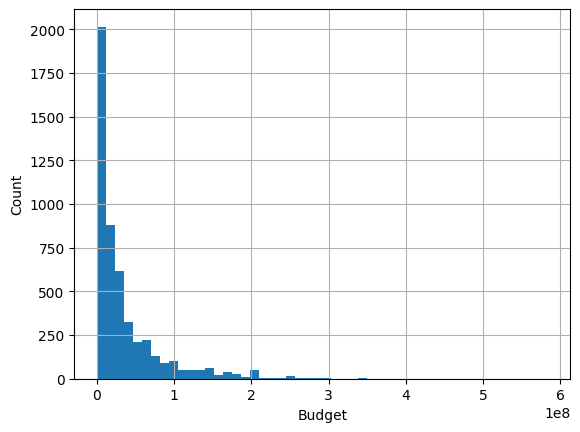

In [205]:
import matplotlib.pyplot as plt

# Histograms (raw dollars)
plt.figure()
movies["revenue"].hist(bins=50)
plt.xlabel("Revenue")
plt.ylabel("Count")
plt.show()

plt.figure()
movies["budget"].hist(bins=50)
plt.xlabel("Budget")
plt.ylabel("Count")
plt.show()


- Both variables are highly skewed, but similarly skewed.

- We will revisit later (especially for revenue, which we are trying to predict).


## Visualize the Relationship Between Budget and Revenue

- Let's create a scatter plot to visualize the relationship between movie budget and revenue

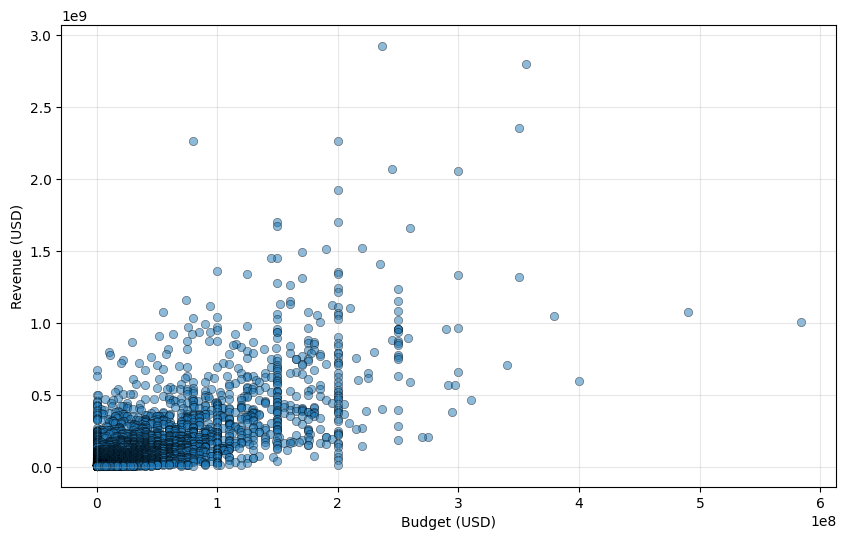

In [206]:
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm

# Scatter plot of budget vs revenue
plt.figure(figsize=(10, 6))
plt.scatter(movies['budget'], movies['revenue'], alpha=0.5, edgecolors='black', linewidth=0.5)
plt.xlabel('Budget (USD)')
plt.ylabel('Revenue (USD)')
plt.grid(True, alpha=0.3)
plt.show()

- Now fit the linear regression with `statmodels` function `OLS`

In [207]:
# Fit linear regression model
X = movies['budget']
y = movies['revenue']
X_with_const = sm.add_constant(X)

model = sm.OLS(y, X_with_const).fit()

- Let's look at the summary of the model fit

In [208]:
# View the model summary
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                revenue   R-squared:                       0.493
Model:                            OLS   Adj. R-squared:                  0.493
Method:                 Least Squares   F-statistic:                     4853.
Date:                Thu, 22 Jan 2026   Prob (F-statistic):               0.00
Time:                        13:43:52   Log-Likelihood:            -1.0124e+05
No. Observations:                5000   AIC:                         2.025e+05
Df Residuals:                    4998   BIC:                         2.025e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.968e+07   2.61e+06      7.547      0.000    1.46e+07    2.48e+07
budget         3.0001      0.043     69.666      0.000       2.916       3.085
==============================================================================
Omnibus:                     4236.337   Durbin-Watson:                   0.892
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           249701.461
Skew:                           3.701   Prob(JB):                         0.00
Kurtosis:                      36.820   Cond. No.                     7.42e+07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 7.42e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

- To visualize the results let's add the linear regresion line on the scatterplot

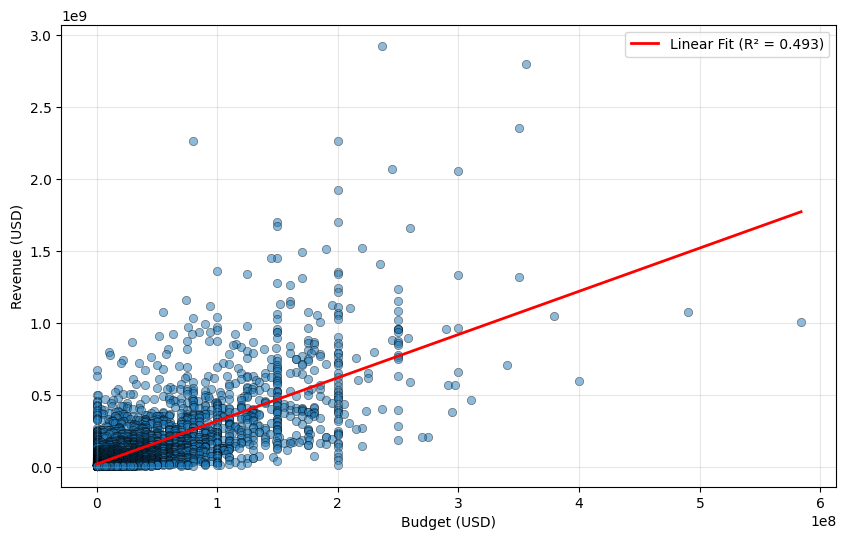

In [209]:
# Add regression line to scatter plot
x_line = np.linspace(X.min(), X.max(), 100)
x_line_with_const = sm.add_constant(x_line)
y_line = model.predict(x_line_with_const)

plt.figure(figsize=(10, 6))
plt.scatter(movies['budget'], movies['revenue'], alpha=0.5, edgecolors='black', linewidth=0.5)
plt.plot(x_line, y_line, 'r-', linewidth=2, label=f'Linear Fit (R² = {model.rsquared:.3f})')
plt.xlabel('Budget (USD)')
plt.ylabel('Revenue (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Interpretation of slope, intercept, p-values, and model fit

We fit a linear regression model with movie revenue as the response and movie budget as the predictor. The fitted model looks like this:

$\widehat{\text{revenue}} = 19{,}679{,}727.45 \;+\; 3.0001 \times \text{budget}$

### Interpretation of the slope:

The estimated slope $\hat \beta_1$ is 3.0001, meaning:

- Holding everything else constant in this one-predictor model, movies with budgets that are $1 higher are associated with $3.00 higher revenue on average.

- More realistically: a $10 million higher budget is associated with about $30.0 million higher revenue on average.

### Interpretation of the intercept

The intercept is about $19.7 million. This is the model’s predicted revenue when Budget = 0.

- This is usually not a meaningful real-world scenario (few real films have exactly $0 budget, and TMDb budgets can be missing/recorded as 0).

- The intercept still matters for defining the regression line, but it’s not typically the focus substantively.

### Interpretation of the p-values

In the regression output, each coefficient (the intercept and the slope) comes with a t-test and a p-value that evaluates:

$$H_0:\ \beta = 0 \quad \text{vs.} \quad H_A:\ \beta \neq 0$$

Intercept p-value:

- The intercept tests whether the expected revenue is zero when the budget is zero. In our output, the intercept p-value is essentially 0 (reported as 0.000), so we reject $H_0: \beta_0 = 0$. This means the fitted intercept is statistically different from zero. However, because a budget of exactly 0 is not very meaningful for most movies, the intercept’s practical interpretation may be limited even if it is statistically significant.

Slope p-value:

- The slope p-value tests whether there is evidence of a linear relationship between budget and revenue. Here, the slope p-value is essentially 0 , so we reject $H_0: \beta_1 = 0$. This provides strong statistical evidence that budget is associated with revenue in this dataset. Because our slope coefficient $\hat \beta_1$ is positive, we interpret that on average, movies with larger budgets tend to have statistically significantly larger revenues.

### Model fit ($R^2$)

- $R^2$, also called the coefficient of determination, describes how well a regression model explains variation in the outcome.

- $R^2$ is the fraction of the variability in y (here, revenue) that is explained by the model’s predictions.

- $R^2$ = 0: the model is no better than predicting the mean of $y$

- $R^2$ = 1: perfect predictions (all predictions fall exactly on the fitted line).

- Our model has $R^2$= 0.4927, meaning the model (budget) explains about 49% of the variability in revenue across the movies in the dataset.

- That’s “moderate” explanatory power for messy observational data: budget is clearly informative, but a lot of variation remains.

- In a prediction context, $R^2$ is more meaningful if we compute it on a **held out test dataset** or by **cross validation**

## Train/test split and why we need it for prediction models

When we fit a regression model, we want to answer different questions:

- How well does the model fit the data we used to estimate it? Can we interpret the regression parameter estimates? (in-sample fit, good for inference)

- How well will the model predict new, unseen movies? (out-of-sample performance)

If we evaluate a model on the same data we trained on, performance can look overly optimistic because the model has “seen” those points already. To get a more honest estimate of predictive performance, we split the dataset into:

- Training set: used to estimate the regression coefficients (fit the model).

- Test set: held out and used only to evaluate predictions.

A common choice is an 80/20 split (80% train, 20% test). The key rule: the test set should not influence model fitting or model tuning (i.e. no data leakage!)

## Example: Split 80% training, 20% test

- The `sklearn.model_selection` library helps us easily split the data into training and test sets. We give it the proportion we want for `test_size` and we set a seed by using `random_state=0`. Setting a seed ensures reproducibility (you get the same train/test split every time you run the code).

In [210]:
from sklearn.model_selection import train_test_split

X = movies[["budget"]]         
y = movies["revenue"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)


- Now let's use `statsmodels` function `OLS` again, but on the training set.

- Show the output.

In [211]:
# Fit model on training set
X_train_const = sm.add_constant(X_train)
model = sm.OLS(y_train, X_train_const).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                revenue   R-squared:                       0.500
Model:                            OLS   Adj. R-squared:                  0.500
Method:                 Least Squares   F-statistic:                     4001.
Date:                Thu, 22 Jan 2026   Prob (F-statistic):               0.00
Time:                        13:43:52   Log-Likelihood:                -81025.
No. Observations:                4000   AIC:                         1.621e+05
Df Residuals:                    3998   BIC:                         1.621e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.888e+07   2.93e+06      6.450      0.000    1.31e+07    2.46e+07
budget         3.0227      0.048     63.257      0.000       2.929       3.116
==============================================================================
Omnibus:                     3583.882   Durbin-Watson:                   1.977
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           254534.911
Skew:                           3.972   Prob(JB):                         0.00
Kurtosis:                      41.263   Cond. No.                     7.48e+07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 7.48e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

#### Question: How do the fitted slope and intercept compare to above?

- look at the coef values, the p-values, the $R^2$

## Predict on test set

- Now we apply the fitted model on the test set to see how well the model predicts unseen data.

In [212]:
# Predict on test set
X_test_const = sm.add_constant(X_test)
y_pred = model.predict(X_test_const)


- We evaluate the model with test $R^2$, test RMSE, and test MAE, these metrics are available in `sklearn.metrics`

- We print each of them out after calculating them

In [213]:
# Calculate test metrics
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

rmse = root_mean_squared_error(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f"Test RMSE: {rmse:,.0f}")
print(f"Test MAE:  {mae:,.0f}")
print(f"Test R²:   {r2:.4f}")

Test RMSE: 145,177,159
Test MAE:  82,885,957
Test R²:   0.4566


### Summary of prediction results

After fitting the regression model on the training set, we evaluated prediction accuracy on the test set (movies not used to fit the model).

- Test RMSE (Root Mean Squared Error) is the square root of the average squared prediction error:
$$\text{RMSE}=\sqrt{\frac{1}{n}\sum_{i=1}^n (y_i-\hat{y}_i)^2}$$

- Our test RMSE = 145,177,159, meaning a typical prediction error is about $145.2 million in a squared-error sense. Because RMSE squares errors before averaging, it penalizes large mistakes more heavily than MAE, so RMSE is often larger when there are big outliers.

- Test MAE (Mean Absolute Error) is the average absolute prediction error:
$$\text{MAE}=\frac{1}{n}\sum_{i=1}^n |y_i-\hat{y}_i|$$

- Our test MAE = 82,885,957, meaning that, on average, the model’s revenue predictions are off by about $82.9 million in absolute dollars.

- Our test $R^2$ = 0.4566 indicates that, on the test set, the model explains about 46% of the variance in revenue compared to a mean-only baseline. This is about the same is what we saw in the training set and the full model, so we aren't overfitting.


### Scatterplot of the observed vs predicted revenue
- A great way to show prediction model results is to plot the predicted values versus the observed values in the test set

- This shows us how well the predictions match what we actually had in the dataset

- Adding a 1-to-1 line shows a "perfect fit" if our model could generate perfect predictions. This is almost never possible to achieve but it allows us to diagnose our prediction model

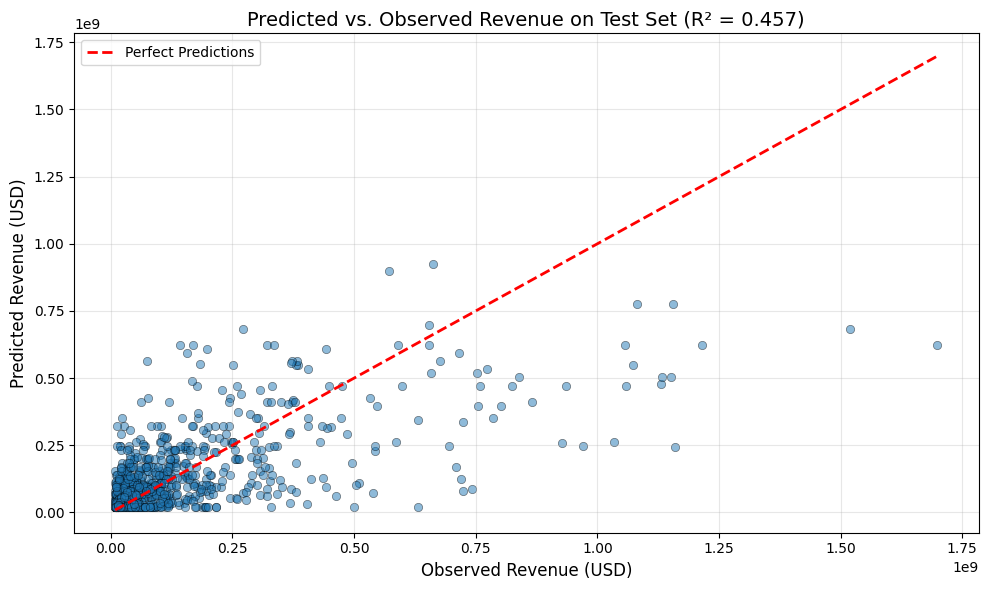

In [214]:
# Scatterplot of predicted vs observed values on test set
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, edgecolors='black', linewidth=0.5)

# Add diagonal reference line (perfect predictions)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Predictions')

plt.xlabel('Observed Revenue (USD)', fontsize=12)
plt.ylabel('Predicted Revenue (USD)', fontsize=12)
plt.title(f'Predicted vs. Observed Revenue on Test Set (R² = {r2:.3f})', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Cross-validation: why it might be more stable

A single train/test split can be “lucky” or “unlucky” depending on which movies happen to land in the test set (especially with outliers like blockbusters). K-fold cross-validation reduces this randomness:

1. Split the dataset into K roughly equal folds.

2. Fit the model K times:

- each time, train on K-1 folds
- test on the remaining fold

3. Average the performance across folds.

This gives a more stable estimate of how the model is expected to perform on new data.


## Example: 5-fold cross-validation


In [215]:
from sklearn.model_selection import KFold

X = movies[["budget"]]
y = movies["revenue"]

# Set up 5-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=0)

- Now we run the CV and store the metrics for each of the 5 folds

- We also store the predictions with the observed values for each fold so we can create a scatterplot of all of the predictions

In [216]:
# Run 5-fold cross-validation
r2_scores = []
rmse_scores = []
mae_scores = []
all_y_test = []
all_y_pred = []

for train_idx, test_idx in kf.split(X):
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]
    
    # Fit model
    X_train_const = sm.add_constant(X_train)
    X_test_const = sm.add_constant(X_test)
    model = sm.OLS(y_train, X_train_const).fit()
    y_pred = model.predict(X_test_const)
    
    # Store metrics
    r2_scores.append(r2_score(y_test, y_pred))
    rmse_scores.append(root_mean_squared_error(y_test, y_pred))
    mae_scores.append(mean_absolute_error(y_test, y_pred))
    
    # Store for plotting
    all_y_test.extend(y_test.values)
    all_y_pred.extend(y_pred.values)

- Average the metrics across the 5 folds

- Print them out to evaluate

In [217]:
# Average results across folds
print(f"Average Test RMSE: {np.mean(rmse_scores):,.0f}")
print(f"Average Test MAE:  {np.mean(mae_scores):,.0f}")
print(f"Average Test R²:   {np.mean(r2_scores):.4f}")

Average Test RMSE: 150,343,021
Average Test MAE:  78,822,483
Average Test R²:   0.4875


#### Question: Do the 5-fold CV results look better than the 80-20 train-test results?

- Compare RMSE:
- Compare MAE:
- Compare $R^2$:

### Make a scatterplot of the observed vs predicted revenue over all 5 folds

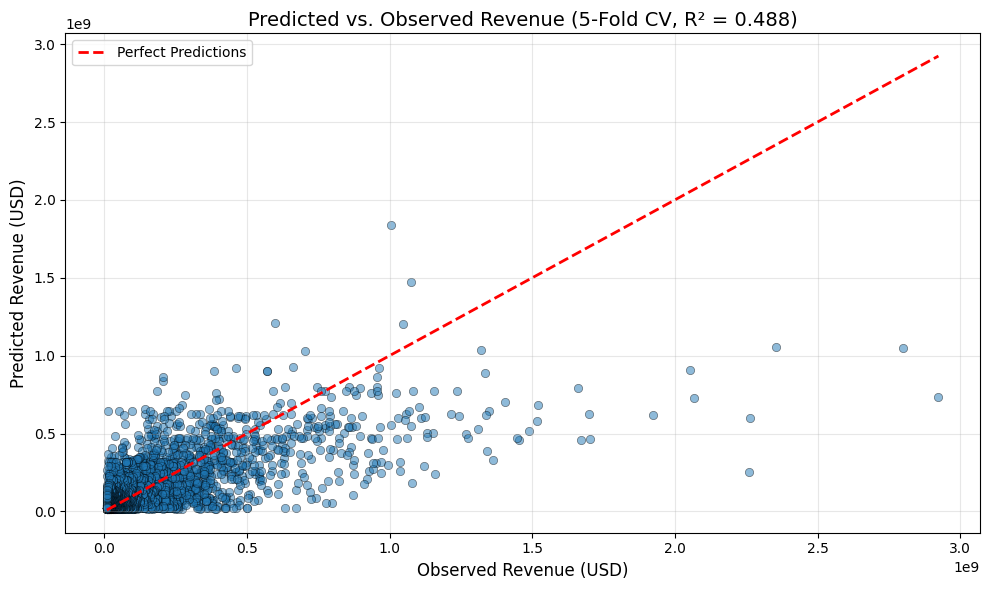

In [218]:
# Scatterplot of predicted vs observed values from 5-fold CV
plt.figure(figsize=(10, 6))
plt.scatter(all_y_test, all_y_pred, alpha=0.5, edgecolors='black', linewidth=0.5)

# Add diagonal reference line (perfect predictions)
min_val = min(min(all_y_test), min(all_y_pred))
max_val = max(max(all_y_test), max(all_y_pred))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Predictions')

plt.xlabel('Observed Revenue (USD)', fontsize=12)
plt.ylabel('Predicted Revenue (USD)', fontsize=12)
plt.title(f'Predicted vs. Observed Revenue (5-Fold CV, R² = {np.mean(r2_scores):.3f})', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Can we improve the model by including more variables in the linear regression?

- We did a decent job of predicting movie revenue from budget alone, but if we add more characteristics of a movie, perhaps we can do an even better job! There were a few more numeric variables, but several that are character variables like production year, genre, production companies, and production countries. 

- We can't use strings in our regression models so we must convert them into numeric variables. This process is often called **feature engineering**.

- We may also want to revisit the skewness in the data by making a **transformation** so that it is more normally distributed, and fits the assumptions of linear regression better.

### Goals of Feature Engineering:
1. Convert character (string) variables to numeric
2. Create different types of numeric variables such as counts, categories, binary 
3. Transform skewed variables, especially what we are trying to predict, for better linear modeling

### Feature Engineering 1. Extract Year from Release Date

- Movies released in different years may have different revenue patterns

- Extract year as a numeric feature

In [219]:
movies['release_year'] = pd.to_datetime(movies['release_date']).dt.year

print(movies[['title', 'release_date', 'release_year']].head())

                      title release_date  release_year
0                    Avatar   2009-12-16          2009
1         Avengers: Endgame   2019-04-24          2019
2  Avatar: The Way of Water   2022-12-14          2022
3                   Titanic   1997-12-18          1997
4                  Ne Zha 2   2025-01-29          2025


### Feature Engineering 2. Count the Number of Genres

- Movies with multiple genres might appeal to broader audiences

- Extract count from comma-separated genre string

In [220]:
movies['num_genres'] = movies['genres'].fillna('').apply(lambda x: len(x.split(',')) if x else 0)

print(movies[['title', 'genres', 'num_genres']].head())

                      title                                    genres  \
0                    Avatar  Action,Adventure,Fantasy,Science Fiction   
1         Avengers: Endgame          Adventure,Science Fiction,Action   
2  Avatar: The Way of Water          Action,Adventure,Science Fiction   
3                   Titanic                             Drama,Romance   
4                  Ne Zha 2        Animation,Fantasy,Adventure,Action   

   num_genres  
0           4  
1           3  
2           3  
3           2  
4           4  


### Feature Engineering 3. Create Binary Indicators for Popular Genres

- Certain genres (Action, Adventure, Sci-Fi) may be associated with higher revenue

- Create binary (0/1) indicator variables for major genres

In [221]:
high_revenue_genres = ['Action', 'Adventure', 'Science Fiction', 'Fantasy']

for genre in high_revenue_genres:
    movies[f'{genre.lower().replace(" ", "_")}'] = movies['genres'].fillna('').str.contains(genre).astype(int)

print(movies[['title', 'genres', 'action', 'adventure', 'science_fiction']].head())

                      title                                    genres  action  \
0                    Avatar  Action,Adventure,Fantasy,Science Fiction       1   
1         Avengers: Endgame          Adventure,Science Fiction,Action       1   
2  Avatar: The Way of Water          Action,Adventure,Science Fiction       1   
3                   Titanic                             Drama,Romance       0   
4                  Ne Zha 2        Animation,Fantasy,Adventure,Action       1   

   adventure  science_fiction  
0          1                1  
1          1                1  
2          1                1  
3          0                0  
4          1                0  


### Feature Engineering 4. Count the Number of Production Companies and Countries

- More production companies/countries might indicate bigger productions

- Extract counts from comma-separated strings

In [222]:
# Count production companies and countries
movies['num_prod_companies'] = movies['production_companies'].fillna('').apply(lambda x: len(x.split(',')) if x else 0)
movies['num_prod_countries'] = movies['production_countries'].fillna('').apply(lambda x: len(x.split(',')) if x else 0)

print(movies[['title', 'num_prod_companies', 'num_prod_countries']].head())

                      title  num_prod_companies  num_prod_countries
0                    Avatar                   4                   2
1         Avengers: Endgame                   1                   1
2  Avatar: The Way of Water                   3                   1
3                   Titanic                   3                   1
4                  Ne Zha 2                   5                   1


### Feature Engineering 5. Create Indicator for US Production

- US-produced movies may have different revenue distributions

- Check if 'US' appears in production countries

In [223]:
# Create indicator for US production
movies['us_production'] = movies['production_countries'].fillna('').str.contains('US').astype(int)

print(movies[['title', 'production_countries', 'us_production']].head(10))

                          title production_countries  us_production
0                        Avatar                US,GB              1
1             Avengers: Endgame                   US              1
2      Avatar: The Way of Water                   US              1
3                       Titanic                   US              1
4                      Ne Zha 2                   CN              0
5  Star Wars: The Force Awakens                   US              1
6        Avengers: Infinity War                   US              1
7       Spider-Man: No Way Home                   US              1
8                    Zootopia 2                   US              1
9                  Inside Out 2                   US              1


### Feature Engineering 6. Log Transformation of Skewed Variables

- Revenue is highly right-skewed, so is budget

- Log transformation can help satisfy linear regression assumptions

- We will apply a log transformation to revenue and budget, but first we need to double check if there are any 0 values because log(0) is infinity (not defined)

In [224]:
# Check for zero values in budget and revenue
print(f"Movies with budget = 0: {(movies['budget'] == 0).sum()}")
print(f"Movies with revenue = 0: {(movies['revenue'] == 0).sum()}")

Movies with budget = 0: 841
Movies with revenue = 0: 0


- There are quite a few budget values that are exactly 0, which is not realistic

- For now we will replace the 0 budget values with a "missing" value indicator, which will remove them from the analysis (linear regression cannot handle missing values in any variable)

In [225]:
# Replace budget = 0 with NaN (likely missing data)
movies.loc[movies['budget'] == 0, 'budget'] = np.nan

- Now let's create the log transformed variables for budget and revenue

In [226]:
# Create log-transformed variables
movies['log_budget'] = np.log(movies['budget'])
movies['log_revenue'] = np.log(movies['revenue'])

print(f"Movies with valid budget (> 0): {movies['budget'].notna().sum()}")
print(f"Movies excluded (budget = 0): {movies['budget'].isna().sum()}")

Movies with valid budget (> 0): 4159
Movies excluded (budget = 0): 841


#### Question: What would be another way to handle 0 values if we want to log transform a variable?

### Summary of Engineered Features

We've created the following features for predicting revenue:

**Numeric Features:**
- `release_year` - year of release
- `num_genres` - number of genres
- `num_prod_companies` - number of production companies
- `num_prod_countries` - number of production countries

**Binary Features:**
- `action` - 1 if Action genre, 0 otherwise
- `adventure` - 1 if Adventure genre, 0 otherwise
- `science_fiction` - 1 if Science Fiction genre, 0 otherwise
- `fantasy` - 1 if Fantasy genre, 0 otherwise
- `us_production` - 1 if produced in US, 0 otherwise

**Transformed Target Variable:**
- `log_revenue` - log-transformed revenue (what we want to predict)

**Original Numeric Variables (already in dataset):**
- `log_budget` - production budget in USD
- `popularity` - TMDB popularity score
- `runtime` - movie duration in minutes
- `vote_average` - average user rating (0-10 scale)
- `actor_avg_pop` - average popularity of top 5 actors
- `crew_avg_pop` - average popularity of top 5 crew members
- `cast_count` - number of cast members
- `crew_count` - number of crew members

## Multiple Linear Regression with Engineered Features

Now let's refit our model using the same 80-20 split, but this time:

- Use `log_revenue` as the response variable (instead of raw revenue)

- Include all the engineered features and original numeric variables as predictors

### Prepare the Data for Multiple Regression

- It is good practice to keep the predictor variables in a list so you can easily add/remove in your model building process

- Then we again prepare the X (now a matrix) and y vector

In [227]:
# Define predictor variables
predictor_cols = [
    'log_budget', 'popularity', 'runtime', 'vote_average',
    'actor_avg_pop', 'crew_avg_pop', 'cast_count', 'crew_count',
    'release_year', 'num_genres', 'num_prod_companies', 'num_prod_countries',
    'action', 'adventure', 'science_fiction', 'fantasy', 'us_production'
]

# Prepare X and y
X = movies[predictor_cols]
y = movies['log_revenue']

- Set up the 80/20 split with the random seed set to 0

In [228]:
# Train/test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

- Fit the model on the training set

In [229]:
# Fit multiple linear regression on training set
X_train_const = sm.add_constant(X_train)
model_multi = sm.OLS(y_train, X_train_const, missing='drop').fit()

- Now that we have a lot of variables, the standard output from `statsmodels` does not show everything

- Instead we can print the training $R^2$ and coefficients table separately

- For a multiple variable linear regression we often look at the adjusted $R^2$, which addresses the fact that there are many variables by adjusting the $R^2$ by the number of $\beta$ parameters being estimated

In [230]:
# Display training R2
model_multi.rsquared_adj

np.float64(0.46423307411375136)

- The important components of the regression output are the coefficient and their errors (p-values)

In [231]:
# View coefficients table
coefs = pd.DataFrame({
    "coef": model_multi.params,
    "std_err": model_multi.bse,
    "t": model_multi.tvalues,
    "p_value": model_multi.pvalues,
})
coefs

,coef,std_err,t,p_value
const,11.52,2.42,4.77,0.00
log_budget,0.32,0.02,20.89,0.00
popularity,0.01,0.00,7.10,0.00
runtime,-0.00,0.00,-2.80,0.01
vote_average,0.16,0.02,8.28,0.00
actor_avg_pop,0.09,0.01,6.54,0.00
crew_avg_pop,0.02,0.03,0.59,0.56
cast_count,0.00,0.00,5.10,0.00
crew_count,0.00,0.00,10.68,0.00
release_year,-0.00,0.00,-0.14,0.89


### Predict on Test Set with Multiple Regression Model

Now let's evaluate how well this multiple regression model performs on the test set.

In [232]:
# Predict on test set
X_test_const = sm.add_constant(X_test)

# Drop rows with NaN values to match what the model was trained on
valid_idx = X_test_const.notna().all(axis=1) & y_test.notna()
X_test = X_test_const[valid_idx]
y_test = y_test[valid_idx]

# Make predictions
y_pred_log = model_multi.predict(X_test)

- Since our revenue variable is log-transformed, first let's calculate the model performance metrics on the log scale 

In [233]:
# Calculate metrics on log scale
rmse_log = root_mean_squared_error(y_test, y_pred_log)
mae_log = mean_absolute_error(y_test, y_pred_log)
r2_log = r2_score(y_test, y_pred_log)

print("Performance on Log Scale:")
print(f"Test RMSE: {rmse_log:.4f}")
print(f"Test MAE:  {mae_log:.4f}")
print(f"Test R²:   {r2_log:.4f}")
print(f"Number of test observations: {len(y_test_clean)}")

Performance on Log Scale:
Test RMSE: 0.9191
Test MAE:  0.7245
Test R²:   0.4426
Number of test observations: 836


- And look at the scatterplot on the log scale

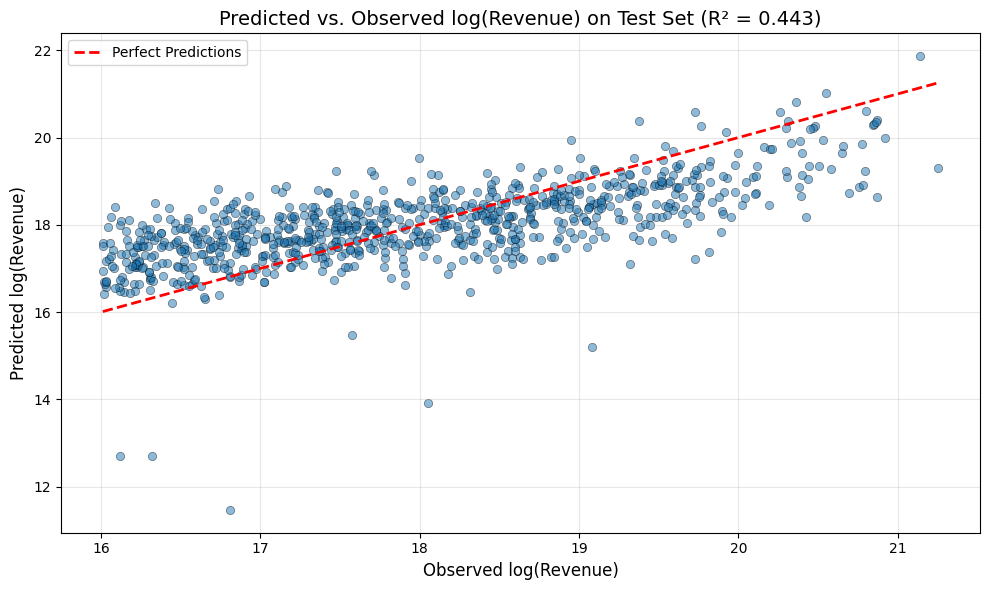

In [234]:
# Scatterplot of predicted vs observed values (on log scale)
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_log, alpha=0.5, edgecolors='black', linewidth=0.5)

# Add diagonal reference line (perfect predictions)
# Use the range of observed values to set limits
obs_min = y_test.min()
obs_max = y_test.max()
plt.plot([obs_min, obs_max], [obs_min, obs_max], 'r--', linewidth=2, label='Perfect Predictions')

plt.xlabel('Observed log(Revenue)', fontsize=12)
plt.ylabel('Predicted log(Revenue)', fontsize=12)
plt.title(f'Predicted vs. Observed log(Revenue) on Test Set (R² = {r2_log:.3f})', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

- Let's now put the predictions and observed back on the original revenue scale ($)

- We have to exponentiate the predictions

In [235]:
# Back transform to original scale by exponentiating the logged predictions and revenue variable
y_test_orig = np.exp(y_test)
y_pred_orig = np.exp(y_pred_log)

In [236]:
# print metrics on the original scale
rmse_orig = root_mean_squared_error(y_test_orig, y_pred_orig)
mae_orig  = mean_absolute_error(y_test_orig, y_pred_orig)
r2_orig   = r2_score(y_test_orig, y_pred_orig)

print("Performance on Original (Revenue) Scale:")
print(f"Test RMSE: {rmse_orig:,.0f}")
print(f"Test MAE:  {mae_orig:,.0f}")
print(f"Test R²:   {r2_orig:.4f}")
print(f"Number of test observations: {len(y_test)}")

Performance on Original (Revenue) Scale:
Test RMSE: 165,285,031
Test MAE:  81,934,611
Test R²:   0.3770
Number of test observations: 836


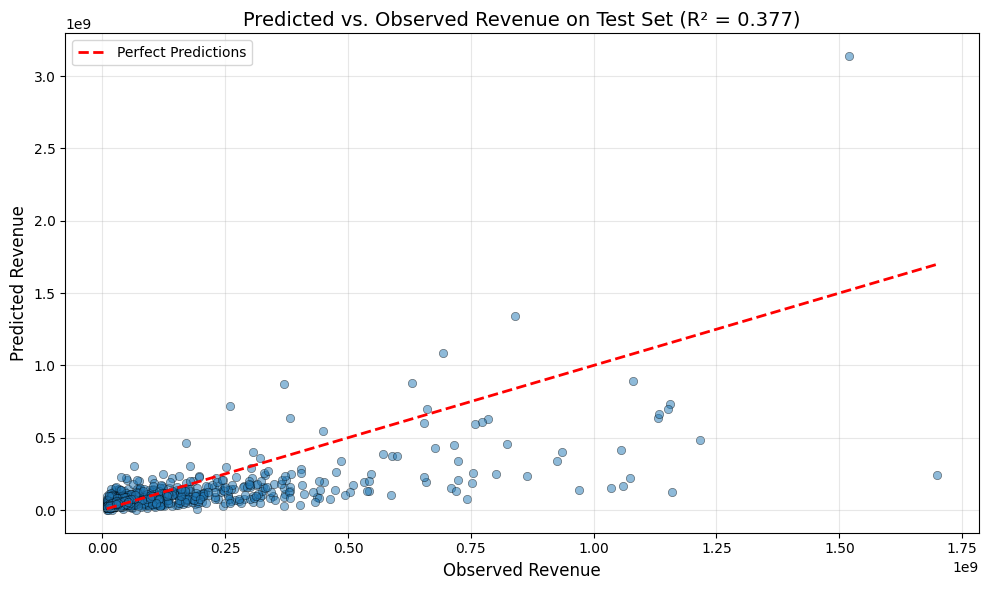

In [237]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test_orig, y_pred_orig, alpha=0.5, edgecolors='black', linewidth=0.5)

obs_min = y_test_orig.min()
obs_max = y_test_orig.max()
plt.plot([obs_min, obs_max], [obs_min, obs_max], 'r--', linewidth=2, label='Perfect Predictions')
plt.xlabel('Observed Revenue', fontsize=12)
plt.ylabel('Predicted Revenue', fontsize=12)
plt.title(f'Predicted vs. Observed Revenue on Test Set (R² = {r2_orig:.3f})', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary: Linear Regression for Prediction

In this lecture, we explored how to build and evaluate linear regression models for predicting movie revenue. Here are the key takeaways:

### Key Concepts

**1. Simple Linear Regression**
- Started with a simple model: predicting revenue from budget alone
- Initial model achieved R² = 0.49, explaining about 49% of variance in revenue
- Found strong positive relationship: every $10M increase in budget associated with ~$30M increase in revenue

**2. Train/Test Split**
- Essential for honest evaluation of predictive performance
- Used 80/20 split (80% training, 20% test) setting `random_state` for reproducibility
- Training set: fit the model (estimate coefficients)
- Test set: evaluate predictions on unseen data
- Prevents overfitting and gives realistic performance estimates

**3. Cross-Validation**
- 5-fold cross-validation provides more stable performance estimates
- Reduces randomness from single train/test split
- Average test $R^2$ = 0.49, consistent with train/test split results

**4. Feature Engineering**
- Transformed character variables into numeric features:
  - **Binary indicators**: action, adventure, science_fiction, fantasy, us_production
  - **Count features**: num_genres, num_prod_companies, num_prod_countries, release_year
- Log-transformed skewed variables (revenue and budget) for better model fit
- Handled missing data: 841 movies with budget = 0 excluded from analysis

**5. Multiple Linear Regression**
- Used 17 predictors including log_budget and engineered features
- Model with log_revenue as response variable
- Training $R^2$ = 0.467, Test $R^2$ = 0.443 (on log scale)
- Key significant predictors:
  - **log_budget** (p < 0.001): strongest predictor
  - **adventure** genre (p < 0.001): large positive effect
  - **popularity** (p < 0.001): positive effect
  - **vote_average** (p < 0.001): higher ratings means higher revenue
  - **actor_avg_pop** (p < 0.001): star power matters

### Model Performance Comparison

| Model | Response | Test R² | Test RMSE | Test MAE |
|-------|----------|---------|-----------|----------|
| Simple (budget only) | revenue | 0.457 | $145M | $83M |
| Multiple (17 predictors, budget = 0 removed) | log(revenue) | 0.443 | 0.919 (log scale) | 0.725 (log scale) |
| Multiple (back transformed scale) | revenue | 0.377 | $165M | $82M |

### Key Insights

1. **Log transformation matters**: Working on log scale improves model assumptions but metrics on original scale show different story

2. **Genre effects**: Adventure films have highest revenue premium; science fiction not significant when controlling for other factors

3. **Diminishing returns**: Adding many predictors didn't dramatically improve $R^2$ compared to simple budget-only model

4. **Interpretability vs. complexity trade-off**: Multiple regression provides richer insights into which factors matter, even if prediction accuracy gains are modest

5. **Need for better EDA**: Some surprises occurred along the way, suggesting that we should do better exploratory data analysis before we dive into modeling

### Limitations

- Many movies missing budget data (17% have budget = 0)

- $R^2$ on original scale (0.377) shows predictions still have substantial error

- Log transformation improves model fit but complicates interpretation

- Observational data - coefficients show associations, not causal effects!

### Next Steps

To improve predictions further, we could:

- Better handle missing budget data. First try not removing (add 1 and then log again) or maybe log is not the best transformation.

- Add more sophisticated features (release month, franchise status, interactions)

- Consider time trends (movie industry changes over years)

- Try non-linear models (decision trees, random forests)



